# Measurement Pipeline

In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Overview</mark>

In this notebook, we will run through a full measurement pipeline. 

Our data are two images of cells stained with phalloidin (F-actin). One image is from an untreated control and one from a drug tretment.
Our question is: **Does the drug change F-actin abundance and/or cell size?**

To find out we will learn how to extract single cell properties using the [**scikit-image**](https://scikit-image.org/docs/stable/) library. Moreover, we will learn how to use the [**pandas**](https://pandas.pydata.org/docs/) library for data handling. Lastly we will brifly introduce [**seaborn**](https://seaborn.pydata.org/) for simple plotting and visualisation.



## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Importing libraries</mark>

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import skimage
import tifffile
from bobiac_tools import overlay_labels

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Load and Display Image and Label Mask</mark>

First we load and display our control image and segmentation. We will walk through how to set up the measurements first and then apply the same strategy to the image of the drug treated cells.

We visualise the image and the segmentation with the overlay function. Hint: if you just want to plot the image use the overlay function with just the image.

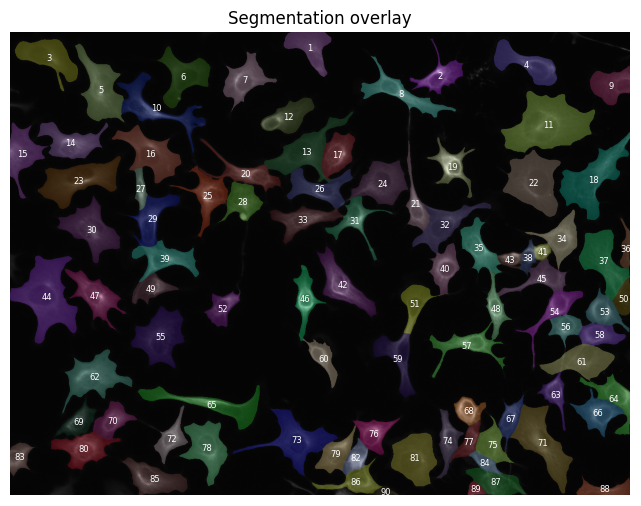

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [5]:
image_path = Path(
    "../../_static/images/quant/01_measurement_quantification/images/F01_202.tif"
)
label_path = Path(
    "../../_static/images/quant/01_measurement_quantification/masks/F01_202_cell_labels.tif"
)

image = tifffile.imread(image_path)[1, :, :]
labeled_mask = tifffile.imread(label_path)

overlay_labels(image, labeled_mask)

Before we use the segmentation to measure, we need to remove all objects that touch the border, since they are likely not fully in the field of view and therefore not measurable.

In [6]:
# remove objects that touch the border of the image
labeled_mask = skimage.segmentation.clear_border(labeled_mask)

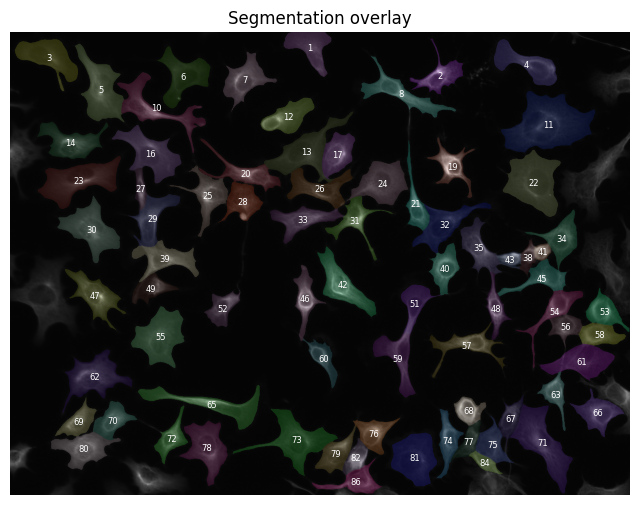

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [7]:
overlay_labels(image, labeled_mask, alpha=0.2)

As we learned before, the labeled mask is a picture the same size of the raw image that has **pixel value 0 for the background** and a **unique integer > 0 for each segmented object** this value we call an objects **index**.
Here, we plotted each segmented object in a different color together with its index.

We can directly access specific objects in our label mask by addressing them using their index.

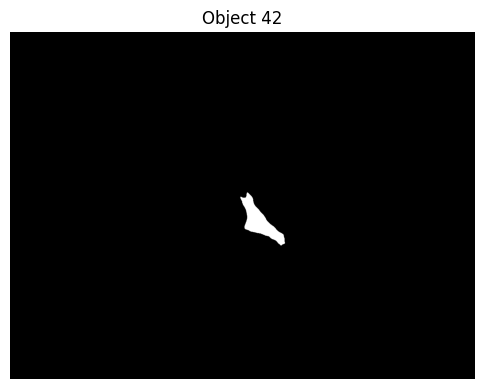

In [8]:
# create an image that contains only the mask of the indexed object
index = 42

idx_object = (
    labeled_mask == index
)  # note that == creates a boolean mask by comparing each pixel to the index value, resulting in True for pixels belonging to the object and False for all other pixels

# Plot the extracted nucleus image
plt.figure(figsize=(6, 6))
plt.imshow(idx_object, cmap="gray")
plt.title(f"Object {index}")
plt.axis("off")
plt.show()

This new image we obtained is a **boolean mask** with value `False` for background and `True` for the object with the index we specified.

To verify that this is indeed a binary mask, we can query for the minimum and maximum value using the `np.min()` and `np.max()` functions:


In [9]:
print("Data type:", idx_object.dtype)

print("Min value:", np.min(idx_object))
print("Max value:", np.max(idx_object))

Data type: bool
Min value: False
Max value: True


## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Manual Extraction of Properties</mark>

Now we can use this mask to measure properties of the object such as its area or the fluorescence intensity of that region in the raw image (i.e. the intensity of the cell).

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Area measurement</mark>
To measure the area of the object we can make use of the fact that the boolean mask is `False` or `0` outside of the object and `True` or `1` inside it.

In [10]:
object_area = np.sum(
    idx_object
)  # counts the number of True pixels, which corresponds to the area of the object in pixels
print(f"Area of object {index}: {object_area} pixels")

Area of object 42: 7395 pixels


To convert the area in pixels to µm, we can multiply it with the squared `pixel size` in µm. Here we assume that one pixels has the size `0.325 µm`.

In [11]:
pixel_size = 0.325  # µm
object_area_um = object_area * (pixel_size**2)
print(f"Area of object {index}: {object_area_um} um^2")

Area of object 42: 781.0968750000001 um^2


### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Intensity measurement</mark>
To measure the objects intensity, we can use the boolean mask to index our raw image.

In [12]:
# Extract the intensity values of the pixels that belong to this nucleus from the original image
object_intesities = image[
    idx_object
]  # this uses the boolean mask to index into the original image

# Print the intensity values and its variable type and shape
print("Type of object_intesities:", type(object_intesities))
print("Shape of object_intesities:", object_intesities.shape)
print(f"Intensity values of object {index}: {object_intesities}")

Type of object_intesities: <class 'numpy.ndarray'>
Shape of object_intesities: (7395,)
Intensity values of object 42: [217 191 214 ... 206 224 197]


We can then calculate the **mean intensity** using the `np.mean()` function:

In [13]:
object_mean_intensity = np.mean(object_intesities)
print(f"Mean intensity of object {index}: {object_mean_intensity}")

Mean intensity of object 42: 886.4260987153482


### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Measure area, basic intensity features for all nuclei in the dataset</mark>

In this exercise, we want to measure for each object in our segmentation mask its area, its mean intensity, the variabilty of its intensity (via standard deviation), and its minimum and maximum intensity values. For this, you can follow these steps:
1. Create an empty list for each feature (e.g. `area_list`).
2. Write a for loop that iterates over all object indices in the segmentation mask.
3. For each iteration measure all features (useful functions are `np.std`, `np.min`, `np.max`) and store them in the corresponding list.
4. Plot each feature as a histogram using `plt.hist`.

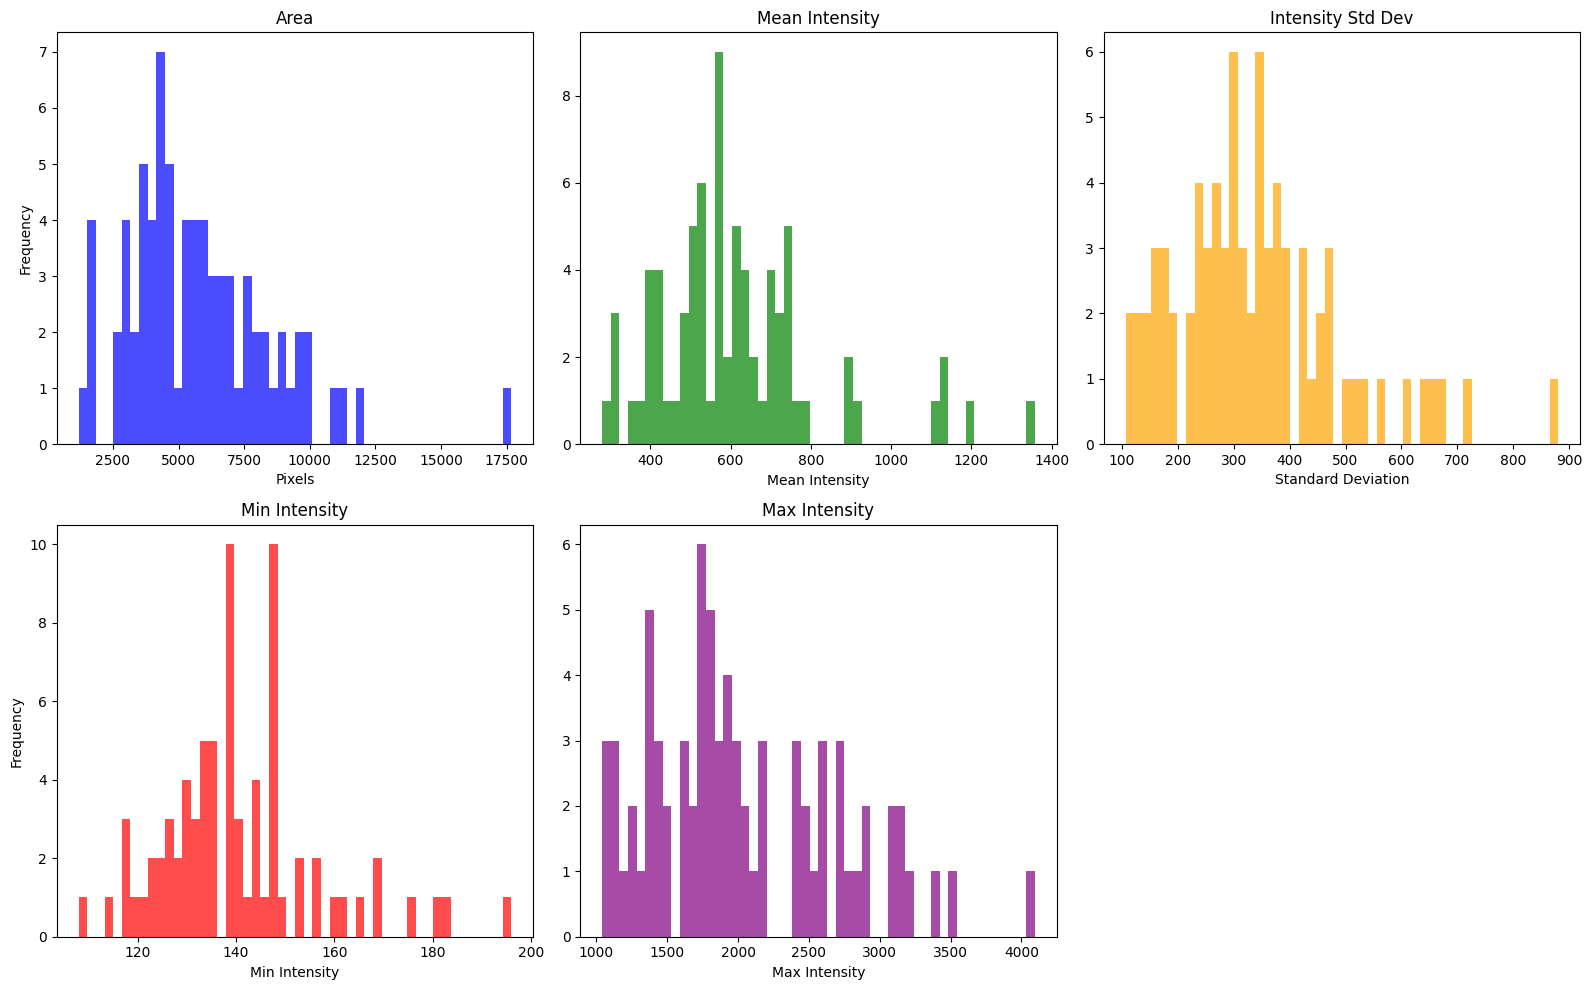

In [14]:
# measure area and intensity statistics for all nuclei in the labeled mask
object_indices = np.unique(labeled_mask)
object_indices = object_indices[object_indices != 0]  # skip background

area_list = []
mean_intensity_list = []
std_intensity_list = []
min_intensity_list = []
max_intensity_list = []

for obj_id in object_indices:
    mask = labeled_mask == obj_id
    intensities = image[mask]

    area_list.append(np.sum(mask))
    mean_intensity_list.append(np.mean(intensities))
    std_intensity_list.append(np.std(intensities))
    min_intensity_list.append(np.min(intensities))
    max_intensity_list.append(np.max(intensities))

# plot histograms for each feature
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.hist(area_list, bins=50, color="blue", alpha=0.7)
plt.title("Area")
plt.xlabel("Pixels")
plt.ylabel("Frequency")

plt.subplot(2, 3, 2)
plt.hist(mean_intensity_list, bins=50, color="green", alpha=0.7)
plt.title("Mean Intensity")
plt.xlabel("Mean Intensity")

plt.subplot(2, 3, 3)
plt.hist(std_intensity_list, bins=50, color="orange", alpha=0.7)
plt.title("Intensity Std Dev")
plt.xlabel("Standard Deviation")

plt.subplot(2, 3, 4)
plt.hist(min_intensity_list, bins=50, color="red", alpha=0.7)
plt.title("Min Intensity")
plt.xlabel("Min Intensity")
plt.ylabel("Frequency")

plt.subplot(2, 3, 5)
plt.hist(max_intensity_list, bins=50, color="purple", alpha=0.7)
plt.title("Max Intensity")
plt.xlabel("Max Intensity")

plt.tight_layout()
plt.show()

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Automated Extraction of Properties</mark>

The [`skimage.measure`](https://scikit-image.org/docs/stable/api/skimage.measure.html) module from **scikit-image** provides efficient tools for measuring properties of labeled image regions, extracting both morphological and intensity-based features for every object in a single call.

A central function in this module is [`regionprops_table`](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops_table):

**Parameters:**
- `label_image` — A 2D or 3D integer array where each unique non-zero value identifies a distinct object.
- `intensity_image` *(optional)* — The corresponding grayscale image, required for intensity-based measurements.
- `properties` — A list of property names to measure and compute. 

For example:

```python
skimage.measure.regionprops_table(label_image, intensity_image=image, properties=["area", "intensity_mean"])
```

**Returns:**
- A `dict` mapping each property name to an array of values, one per labeled object.

The table below summarizes commonly used properties:

| Measurement | Description |
|-------------|-------------|
| area | Number of pixels in the object (size) |
| perimeter | Approximate boundary length |
| eccentricity | Elongation of the shape (0 = circle, 1 = line segment) |
| solidity | Ratio of object area to its convex hull area |
| orientation | Angle of the major axis relative to the horizontal |
| intensity_mean | Mean pixel intensity within the region |
| intensity_std | Standard deviation of pixel intensities within the region |
| intensity_max | Maximum pixel intensity within the region |
| intensity_min | Minimum pixel intensity within the region |
| image_intensity | Pixel values cropped to the object's bounding box |
| centroid | Center of mass coordinates |
| bbox | Bounding box coordinates |
| coords | List of coordinates of all pixels (y, x) |

A full list of all measurable properties can be found in the [regionprops documentation](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops).

Use `regionprops_table` to extract measurements from `labeled_mask` and `image`:

In [15]:
# compute label, area, and mean intensity for each object in the label mask
props = skimage.measure.regionprops_table(
    labeled_mask, image, ["label", "area", "intensity_mean"]
)
print("Datatype:", type(props))
print("Keys in props:", list(props.keys()))
print(" ")
print("All features for all objects:\n", props)

Datatype: <class 'dict'>
Keys in props: ['label', 'area', 'intensity_mean']
 
All features for all objects:
 {'label': array([ 1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 16, 17, 19, 20,
       21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 38, 39,
       40, 41, 42, 43, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58,
       59, 60, 61, 62, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76,
       77, 78, 79, 80, 81, 82, 84, 86]), 'area': array([ 5634.,  4728.,  7677.,  6824.,  9638.,  7597.,  6457.,  6623.,
        8089., 17676.,  5623.,  9464.,  6870.,  8757.,  5192.,  4511.,
        5498.,  3704., 11958., 10928.,  8255.,  5922.,  6221.,  1790.,
        4905.,  5894.,  9128.,  4602.,  7087.,  5809.,  5392.,  5493.,
        1726.,  6322.,  4469.,  1193.,  7395.,  1526.,  4674.,  4392.,
        6731.,  3363.,  3606.,  4110.,  3619.,  4218.,  4654.,  9771.,
        3111.,  5339.,  3853.,  5943.,  3227.,  7514.,  9025.,  3037.,
        7956.,  5224.,  3094.,  303

`regionprops_table` creates a dictionary where the keys are the names of the properties and the values are numpy arrays of the measurements of the properties for all objects in the label mask. We can access all area measurements like this: `props['area']` and an object-specific area measurement like this: `props['area'][index]` with `index` being e.g. `0` for the first object. The order of objects is the same across all property arrays.

In [16]:
print("Area for all objects:\n", props["area"])
print()
# we use index-1 because the label IDs start at 1, but list indexing starts at 0
print(f"Area for object {index}:", props["area"][index - 1])

Area for all objects:
 [ 5634.  4728.  7677.  6824.  9638.  7597.  6457.  6623.  8089. 17676.
  5623.  9464.  6870.  8757.  5192.  4511.  5498.  3704. 11958. 10928.
  8255.  5922.  6221.  1790.  4905.  5894.  9128.  4602.  7087.  5809.
  5392.  5493.  1726.  6322.  4469.  1193.  7395.  1526.  4674.  4392.
  6731.  3363.  3606.  4110.  3619.  4218.  4654.  9771.  3111.  5339.
  3853.  5943.  3227.  7514.  9025.  3037.  7956.  5224.  3094.  3038.
  3670.  4349. 11120.  3664.  9978.  4029.  4096.  4163.  2607.  8142.
  4289.  6577.  8947.  2622.  1669.  4207.]

Area for object 42: 3363.0


As you can see, we get the same area value we obtained manually before.

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Use `regionprops_table` to measure basic features of all nuclei</mark>

In this exercise, we repeat the exercise above using `regionprops_table` instead of looping over each object.
Measure `area`, `intensity_mean`, `intensity_std`, `intensity_max`, `intensity_min`, and (this one is new) `perimeter`.
For that you can:
1. Use regionprops with the appropriate properties.
2. Use `plt.hist` to plot a histogram for each property. (You can use a for loop for that if you want to be efficient.)

Note how much less code you have to write compared with the previous exercise.

Bonus: think about how you would implement the `perimeter` property manually. 

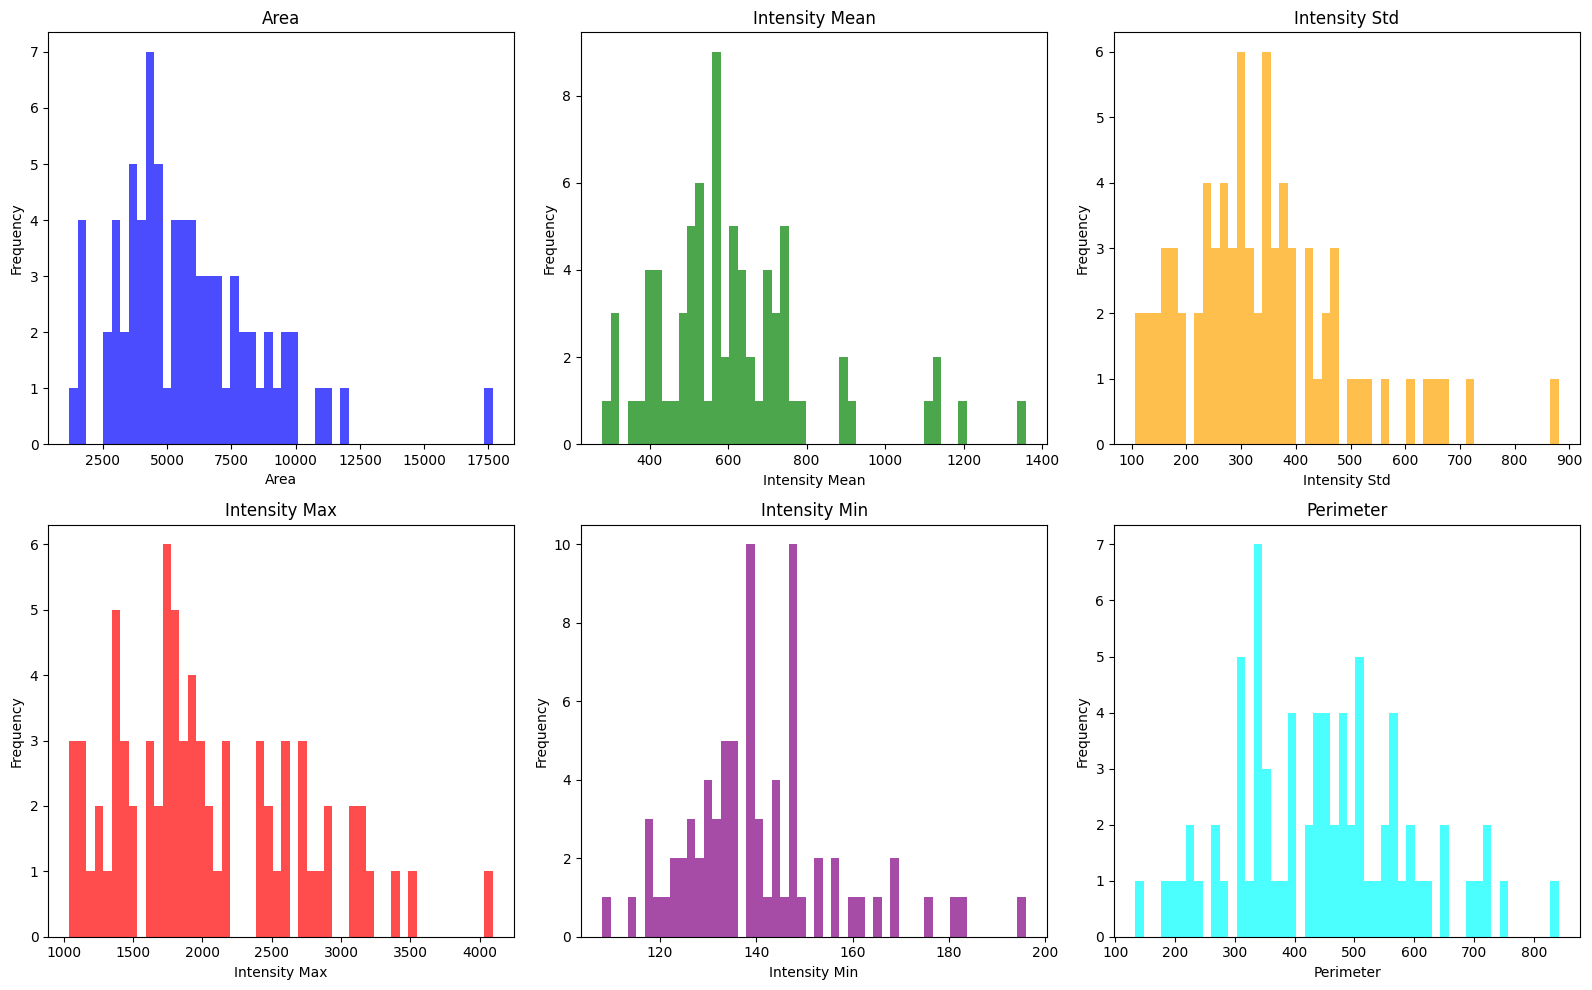

In [17]:
properties = [
    "area",
    "intensity_mean",
    "intensity_std",
    "intensity_max",
    "intensity_min",
    "perimeter",
]

props_basic = skimage.measure.regionprops_table(
    labeled_mask, intensity_image=image, properties=properties
)

list_colors = ["blue", "green", "orange", "red", "purple", "cyan"]

plt.figure(figsize=(16, 10))
for i, prop in enumerate(properties, start=1):
    plt.subplot(2, 3, i)
    plt.hist(props_basic[prop], bins=50, color=list_colors[i - 1], alpha=0.7)
    plt.title(prop.replace("_", " ").title())
    plt.xlabel(prop.replace("_", " ").title())
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Tables -> `pandas.DataFrame`</mark>
Using `lists`, `dictionaries` and `np.arrays` for data analysis works fine, but is a little bit clunky. Here, we introduce a more streamlined and straightforward method for storing and accessing your data. We use the `pandas` package which is centred around the `DataFrame` object, an intuitive 2D table that allows basic plotting, labelling of rows, columns and conditional indexing as well as table operations such as `melt` and `pivot` and summary statistics like `mean` or `std`. 

This is a brief interlude before we return to comparing our control and drug treated cells. It will be worth it in the end.

We start by importing `pandas` and creating a new `DataFrame` variable.

In [18]:
import pandas as pd

properties = [
    "area",
    "intensity_mean",
    "intensity_std",
    "intensity_max",
    "intensity_min",
    "perimeter",
]
props = skimage.measure.regionprops_table(
    labeled_mask, intensity_image=image, properties=properties
)

df = pd.DataFrame(props)
print(df)

      area  intensity_mean  intensity_std  intensity_max  intensity_min  \
0   5634.0      422.204295     198.333981         1118.0          132.0   
1   4728.0      764.301607     523.274140         3509.0          138.0   
2   7677.0      279.368894     125.690020         1069.0          118.0   
3   6824.0      433.457210     254.054528         1445.0          120.0   
4   9638.0      492.971571     267.211757         1934.0          123.0   
..     ...             ...            ...            ...            ...   
71  6577.0      693.653337     335.493382         1762.0          147.0   
72  8947.0      314.865094     106.334739         1124.0          162.0   
73  2622.0     1197.801678     717.324747         3076.0          175.0   
74  1669.0      753.530258     221.434922         1388.0          196.0   
75  4207.0      716.490373     264.225298         1605.0          181.0   

     perimeter  
0   376.877200  
1   516.416306  
2   502.031529  
3   444.132034  
4   570.535101

Note how tidy this format is. Individual cells are `rows` containing all measuremnt that relate to that cell and `columns` are sets of measurements for all cells.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Accessing data in `DataFrames`</mark>
Accessing columns works similar to dictionaries: `df[column]` or `df[[list_of_columns]]`.

In [19]:
# Print just the area column
print(df["area"])

0     5634.0
1     4728.0
2     7677.0
3     6824.0
4     9638.0
       ...  
71    6577.0
72    8947.0
73    2622.0
74    1669.0
75    4207.0
Name: area, Length: 76, dtype: float64


In [20]:
# Print area and mean intensity columns
print(df[["area", "intensity_mean"]])

      area  intensity_mean
0   5634.0      422.204295
1   4728.0      764.301607
2   7677.0      279.368894
3   6824.0      433.457210
4   9638.0      492.971571
..     ...             ...
71  6577.0      693.653337
72  8947.0      314.865094
73  2622.0     1197.801678
74  1669.0      753.530258
75  4207.0      716.490373

[76 rows x 2 columns]


Accessing rows can be done via `index` using `.iloc` or by condition using `.loc`.

First we can access all the properties of the previously selected cell `42`.

In [21]:
# again, we use index-1 to access the correct row corresponding to the object with label ID equal to index
print(df.iloc[index - 1])

area              3363.000000
intensity_mean     921.250074
intensity_std      559.656385
intensity_max     2871.000000
intensity_min      144.000000
perimeter          388.634560
Name: 41, dtype: float64


We can index conditionally based on properties. Here we select all cells with an area larger than 3000 pixels.

In [22]:
print(df[df["area"] > 3000])

      area  intensity_mean  intensity_std  intensity_max  intensity_min  \
0   5634.0      422.204295     198.333981         1118.0          132.0   
1   4728.0      764.301607     523.274140         3509.0          138.0   
2   7677.0      279.368894     125.690020         1069.0          118.0   
3   6824.0      433.457210     254.054528         1445.0          120.0   
4   9638.0      492.971571     267.211757         1934.0          123.0   
..     ...             ...            ...            ...            ...   
69  8142.0      492.208548     225.113748         1723.0          139.0   
70  4289.0      563.035206     310.288222         1863.0          144.0   
71  6577.0      693.653337     335.493382         1762.0          147.0   
72  8947.0      314.865094     106.334739         1124.0          162.0   
75  4207.0      716.490373     264.225298         1605.0          181.0   

     perimeter  
0   376.877200  
1   516.416306  
2   502.031529  
3   444.132034  
4   570.535101

To fully understand what happened there, we break this line into parts.

In [23]:
# this creates a boolean Series where each value is True if the corresponding row in the 'area' column is greater than 3000, and False otherwise
bool_series = df["area"] > 3000
print("boolean Series:\n", bool_series)
# then we use this boolean Series to index into the DataFrame, which returns only the rows where the condition is True, i.e., where the area is greater than 3000 pixels
print("\nFiltered DataFrame:\n", df[bool_series])

boolean Series:
 0      True
1      True
2      True
3      True
4      True
      ...  
71     True
72     True
73    False
74    False
75     True
Name: area, Length: 76, dtype: bool

Filtered DataFrame:
       area  intensity_mean  intensity_std  intensity_max  intensity_min  \
0   5634.0      422.204295     198.333981         1118.0          132.0   
1   4728.0      764.301607     523.274140         3509.0          138.0   
2   7677.0      279.368894     125.690020         1069.0          118.0   
3   6824.0      433.457210     254.054528         1445.0          120.0   
4   9638.0      492.971571     267.211757         1934.0          123.0   
..     ...             ...            ...            ...            ...   
69  8142.0      492.208548     225.113748         1723.0          139.0   
70  4289.0      563.035206     310.288222         1863.0          144.0   
71  6577.0      693.653337     335.493382         1762.0          147.0   
72  8947.0      314.865094     106.334739  

A variety of different logical operations can be used for **conditional indexing** via `.loc`.
Those include: `<`, `>`, `<=`, `>=`, `==`, `!=` (not equal to), `.isin(list)` (equal to any object in list), `~` (not). Morover, multiple conditions can be chained using `&` (and), `|` (or) operators (each condition has to be in `()` parenthesis for this). Visit the excellent [pandas tutorial](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html) on selecting subsets from DataFrames for more details.

In [24]:
# select all rows where area is greater than 2000 pixels and mean intensity is less than 400 and print their perimeter values
filtered_df = df[(df["area"] > 2000) & (df["intensity_mean"] < 350)]
print(filtered_df)

       area  intensity_mean  intensity_std  intensity_max  intensity_min  \
2    7677.0      279.368894     125.690020         1069.0          118.0   
5    7597.0      316.810846     124.751047         1243.0          124.0   
18  11958.0      303.405001     109.566139         1173.0          108.0   
53   7514.0      346.961672     147.307176         1040.0          132.0   
72   8947.0      314.865094     106.334739         1124.0          162.0   

     perimeter  
2   502.031529  
5   486.629509  
18  507.972655  
53  432.451840  
72  392.776695  


In [25]:
# select all rows where area is exactly 12061 or 9504 pixels
filtered_df = df[df["area"].isin([12061, 9504])]
print(filtered_df)

Empty DataFrame
Columns: [area, intensity_mean, intensity_std, intensity_max, intensity_min, perimeter]
Index: []


In [26]:
# select all rows where the intensity is between 400 and 750
filtered_df = df[(df["intensity_mean"] >= 400) & (df["intensity_mean"] <= 750)]
print(filtered_df)

       area  intensity_mean  intensity_std  intensity_max  intensity_min  \
0    5634.0      422.204295     198.333981         1118.0          132.0   
3    6824.0      433.457210     254.054528         1445.0          120.0   
4    9638.0      492.971571     267.211757         1934.0          123.0   
6    6457.0      537.645656     309.074083         2414.0          133.0   
7    6623.0      609.066888     378.843471         2428.0          135.0   
8    8089.0      526.768327     416.895764         2463.0          132.0   
10   5623.0      553.856304     399.380371         2585.0          127.0   
12   6870.0      532.893159     342.724796         2445.0          141.0   
13   8757.0      417.785086     192.811960         1760.0          136.0   
14   5192.0      647.297766     386.178570         2808.0          147.0   
16   5498.0      714.181884     467.629040         2493.0          147.0   
19  10928.0      407.137079     230.782862         2197.0          127.0   
20   8255.0 

In [27]:
# select all rows where the area is smaller than 10 pixels
filtered_df = df[df["area"] < 10]
print(filtered_df)

Empty DataFrame
Columns: [area, intensity_mean, intensity_std, intensity_max, intensity_min, perimeter]
Index: []


Note that if no criterion in `.loc` is met, we get an `Empty DataFrame`.

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Use `iloc` and `loc` to access specific measurements in the `DataFrame`</mark>

In this exercise, use the `iloc` and `loc` indexers to access specific entries of `df`.
1. Print only the first ten rows.
2. Print all rows where the `perimeter` is smaller than 140 pixels.
3. Print all rows where the `area` is smaller than 1500 pixesl or the `minimum intensity` exceeds 0.08.
4. BONUS: Print the `area` of all rows where `instensity_std` is less than 100.

In [79]:
# 1. Print only the first ten rows
print("First ten rows:")
print(df.iloc[:10])
print("\n" + "=" * 80 + "\n")

# 2. Print all rows where the perimeter is smaller than 140 pixels
print("Rows where perimeter < 140:")
print(df[df["perimeter"] < 140])
print("\n" + "=" * 80 + "\n")

# 3. Print all rows where area is smaller than 1500 pixels OR minimum intensity exceeds 0.08
print("Rows where area < 1500 OR intensity_min > 0.08:")
print(df[(df["area"] < 1500) | (df["intensity_min"] > 0.08)])
print("\n" + "=" * 80 + "\n")

# 4. BONUS: Print the area of all rows where intensity_std is less than 100
print("Area of rows where intensity_std < 100:")
print(df[df["intensity_std"] < 100]["area"])

First ten rows:
      area  intensity_mean  intensity_std  intensity_max  intensity_min  \
0   5634.0      422.204295     198.333981         1118.0          132.0   
1   4728.0      764.301607     523.274140         3509.0          138.0   
2   7677.0      279.368894     125.690020         1069.0          118.0   
3   6824.0      433.457210     254.054528         1445.0          120.0   
4   9638.0      492.971571     267.211757         1934.0          123.0   
5   7597.0      316.810846     124.751047         1243.0          124.0   
6   6457.0      537.645656     309.074083         2414.0          133.0   
7   6623.0      609.066888     378.843471         2428.0          135.0   
8   8089.0      526.768327     416.895764         2463.0          132.0   
9  17676.0      390.690258     175.981511         1312.0          118.0   

    perimeter  intensity_mean_bg_subtracted  intensity_range  cell_id  \
0  376.877200                    294.955703            986.0        1   
1  516.41630

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Create new columns and math on columns</mark>
The `DataFrame` format allows us to do calculations using whole columns and to save the results in new columns. This is very useful for doing calculations on the raw measurements.

Let's measure the background intensity and subtract it from the mean intensity of all objects

In [29]:
# calculate bg intensity
background_intensity = image[
    labeled_mask == 0
].mean()  # this calculates the mean intensity of all pixels in the original image that belong to the background (where labeled_mask == 0)
print("Background intensity:", background_intensity, "\n")
print(
    "Mean intensity (background-subtracted):\n",
    df["intensity_mean"] - background_intensity,
)

Background intensity: 127.24859276905134 

Mean intensity (background-subtracted):
 0      294.955703
1      637.053015
2      152.120301
3      306.208617
4      365.722978
         ...     
71     566.404745
72     187.616502
73    1070.553085
74     626.281665
75     589.241780
Name: intensity_mean, Length: 76, dtype: float64


In [30]:
# We can store the background-subtracted mean intensity in a new column in the DataFrame
df["intensity_mean_bg_subtracted"] = df["intensity_mean"] - background_intensity
print(df[["intensity_mean", "intensity_mean_bg_subtracted"]])

    intensity_mean  intensity_mean_bg_subtracted
0       422.204295                    294.955703
1       764.301607                    637.053015
2       279.368894                    152.120301
3       433.457210                    306.208617
4       492.971571                    365.722978
..             ...                           ...
71      693.653337                    566.404745
72      314.865094                    187.616502
73     1197.801678                   1070.553085
74      753.530258                    626.281665
75      716.490373                    589.241780

[76 rows x 2 columns]


Note how intuitive this syntax is. We can also do calculations using multiple rows of the DataFrame.

Let's calculate the difference between the maximum and minimum intensity for each object and store it in a new column called `intensity_range`.

In [31]:
df["intensity_range"] = df["intensity_max"] - df["intensity_min"]
print(df[["intensity_max", "intensity_min", "intensity_range"]])

    intensity_max  intensity_min  intensity_range
0          1118.0          132.0            986.0
1          3509.0          138.0           3371.0
2          1069.0          118.0            951.0
3          1445.0          120.0           1325.0
4          1934.0          123.0           1811.0
..            ...            ...              ...
71         1762.0          147.0           1615.0
72         1124.0          162.0            962.0
73         3076.0          175.0           2901.0
74         1388.0          196.0           1192.0
75         1605.0          181.0           1424.0

[76 rows x 3 columns]


### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Create a couple of new columns</mark>

1. Create a column called `cell_id` containing integer values that correspond to the value of the object in the label mask.
2. Create a column called `sum_intensity` that contains the sum of all pixel intensities (mean intensity * number of pixels).
3. BONUS: Create a column called `circularity` that is 1 if an object is perfectly circular and goes towards 0 otherwise.

In [32]:
df["cell_id"] = object_indices
df["intensity_sum"] = df["intensity_mean"] * df["area"]
df["circularity"] = 4 * np.pi * df["area"] / (df["perimeter"] ** 2)

# this prints the first 5 rows of the DataFrame, showing the new columns we created
print(df[["cell_id", "intensity_sum", "circularity"]].head())

   cell_id  intensity_sum  circularity
0        1      2378699.0     0.498456
1        2      3613618.0     0.222786
2        3      2144715.0     0.382771
3        4      2957912.0     0.434735
4        5      4751260.0     0.372076


### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Numerical and categorical values</mark>
So far we have only used numerical values in our `DataFrame` such as `area` (which is expressed as a number). However, in `pandas` (and data analysis generally) we may also use categorical values. Examples are classified gene expression (`expressing`) which could be `none`, `low`, `high` or experimental conditions like `condition` which may be `control`,  `drug`.

First we create a new column called `image_id` that contains the same value for all rows, which is the name of the image we analyzed.

In [33]:
df["image_id"] = image_path.stem  # this extracts the filename without the extension
# this prints the first 5 rows of the DataFrame, showing the new column we created
print(df[["image_id"]].head())

  image_id
0  F01_202
1  F01_202
2  F01_202
3  F01_202
4  F01_202


This might look redundant, but will be very important when analysing multiple images and a key part of keeping track of the source of data. With this notation, `cell_id` and `image_id` combined can identify every object across a whole dataset of however many images.

Let's classify area into three categories: small (< 4000 pixels), medium (4000-8000 pixels), and large (> 8000 pixels) and store this in a new column called `size_category`

In [34]:
df["size_category"] = pd.cut(
    df["area"], bins=[0, 4000, 8000, np.inf], labels=["small", "medium", "large"]
)
print(df["size_category"].unique())

['medium', 'large', 'small']
Categories (3, object): ['small' < 'medium' < 'large']


Next, we classify intensity_mean into three categories: low, medium, and high, and store the category in a new column called `expression`.

In [35]:
df["expression"] = pd.cut(
    df["intensity_mean"], bins=[0, 400, 750, np.inf], labels=["none", "low", "high"]
)
print(df["expression"].unique())

['low', 'high', 'none']
Categories (3, object): ['none' < 'low' < 'high']


### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Create some categorical columns</mark>
1. Make a new column called `condition` and assign it the value `control`.
2. Classify `intensity_sum` into `low` and `high` using the threshold `400` and store the classification in a column called `sum_classified`.
3. BONUS: classify the circularity of the objects into three classes. Think about what would be meaningful thresholds.

In [36]:
df["condition"] = "control"
df["sum_classified"] = np.where(df["intensity_sum"] > 400, "high", "low")
df["circularity_class"] = pd.cut(
    df["circularity"],
    # 0-0.6 is a very non-circular (a equilateral triangle has 0.6), 0.9-1 is a relatively circular (a hexagon has 0.9)
    bins=[0, 0.6, 0.9, 1],
    labels=["low", "medium", "high"],
)

print(df[["condition", "sum_classified", "circularity_class"]].head())

  condition sum_classified circularity_class
0   control           high               low
1   control           high               low
2   control           high               low
3   control           high               low
4   control           high               low


## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Overlay measurements on the image</mark>
For quality control or exploration it is important to overlay measured quantities on the original image. Here we use the `overlay` function for that.

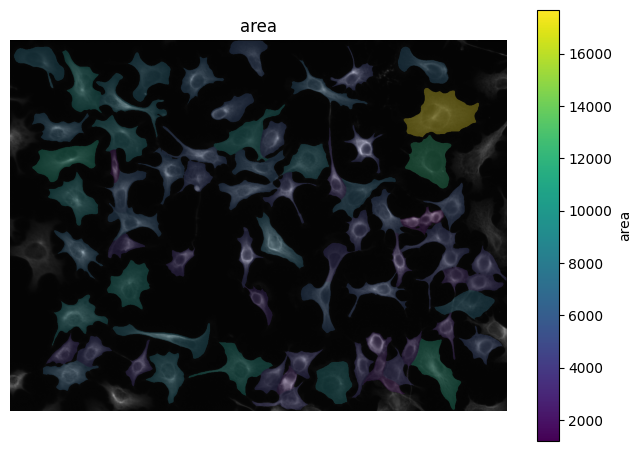

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'area'}>)

In [37]:
overlay_labels(image, labeled_mask, df=df, id_col="cell_id", measurement_col="area")

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Calculate summary statistics and correlation</mark>
Pandas gives us the ability to very effectively compute common summary statistics like mean, median, standard deviation, standard error, etc. on either whole columns or on subsets via aggregation (split by a categorical variable).

In [38]:
# print the average area of all objects
mean_area = df["area"].mean()
print(f"Average area across all objects: {mean_area:.2f} pixels")

Average area across all objects: 5792.17 pixels


In [39]:
# print common statistics for the area feature
print("Area statistics:")
print(f"Mean: {df['area'].mean():.2f} pixels")
print(f"Median: {df['area'].median():.2f} pixels")
print(f"Standard Deviation: {df['area'].std():.2f} pixels")
print(f"Minimum: {df['area'].min()} pixels")
print(f"Maximum: {df['area'].max()} pixels")

Area statistics:
Mean: 5792.17 pixels
Median: 5365.50 pixels
Standard Deviation: 2800.20 pixels
Minimum: 1193.0 pixels
Maximum: 17676.0 pixels


In [40]:
# We can more effectively summarize common features using .describe()
print(df["area"].describe())

count       76.000000
mean      5792.171053
std       2800.202628
min       1193.000000
25%       3985.000000
50%       5365.500000
75%       7424.750000
max      17676.000000
Name: area, dtype: float64


In [41]:
# The .agg() method allows us to specify multiple statiscs at once.
print(df["area"].agg(["mean", "median", "std", "min", "max"]))

mean       5792.171053
median     5365.500000
std        2800.202628
min        1193.000000
max       17676.000000
Name: area, dtype: float64


This is a table of common statistics that can be used either as e.g. `df['area'].mean()` or `df['area'].agg(['mean'])`.

| Function | Description |
|----------|-------------|
| count | Number of non-NA observations |
| value_counts | Number of observations per category |
| sum | Sum of values |
| mean | Mean of values |
| median | Arithmetic median of values |
| min | Minimum |
| max | Maximum |
| std | Bessel-corrected sample standard deviation |
| var | Unbiased variance |
| sem | Standard error of the mean |
| skew | Sample skewness (3rd moment) |
| kurt | Sample kurtosis (4th moment) |

We can group (aggregate) the data by categories and calculate summary statistics on each group. This is very useful if we e.g. want to find out if cells that have received a treatment are expressing upregulate a gene or exhibit morphological differences.

We achieve this by using the `.groupby()` method.

First, let's group objects by size category (small, medium, large) based on `size_category` and calculate the average `intensity_mean` for each size category.

In [42]:
df.groupby(["size_category"])["intensity_mean"].mean()

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_38450/362759293.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["size_category"])["intensity_mean"].mean()


size_category
small     776.428066
medium    602.484704
large     436.542845
Name: intensity_mean, dtype: float64

We can also group by multiple categories at once. Here we group by `size_category` and `expression` and we evaluate the mean circularity. 

In [43]:
df.groupby(["size_category", "expression"])["circularity"].mean()

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_38450/2404442296.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["size_category", "expression"])["circularity"].mean()


size_category  expression
small          none               NaN
               low           0.446059
               high          0.537791
medium         none          0.430270
               low           0.357371
               high          0.265920
large          none          0.470875
               low           0.384508
               high               NaN
Name: circularity, dtype: float64

The `NaN` above indicate that there exist no observation with that combination of categories.

Another very useful statistic to calculate is the correlation between two columns per observation. For this we can use the `.corr()` method.

In [44]:
# calculate the correlation between area and mean intensity
correlation = df["area"].corr(df["intensity_mean"])
print(f"Correlation between area and mean intensity: {correlation:.2f}")

Correlation between area and mean intensity: -0.62


### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Combine data from multiple `DataFrames`</mark>
To combine data, e.g. from multiple images or experimental days, it is often necessary to combine dataframes. While this is straightforward, it is important to pay attention to proper 'book keeping' because it is easy to lose track of where data comes from and what conditions are associated with it. 

Here we will load the mask and image of the drug treated condition, and measure properties using `regionprops_table`. We then combine it with our exiting dataframe.

In [46]:
# define the paths to the second image and its corresponding label mask
image_path_2 = Path(
    "../../_static/images/quant/01_measurement_quantification/images/F02_92.TIF"
)
label_path_2 = Path(
    "../../_static/images/quant/01_measurement_quantification/masks/F02_92_cell_labels.tif"
)

# load the second image and label mask
image_2 = tifffile.imread(image_path_2)[1, :, :]
labeled_mask_2 = tifffile.imread(label_path_2)
labeled_mask_2 = skimage.segmentation.clear_border(
    labeled_mask_2
)  # remove boundary objects

# compute region properties for the second image
props_2 = skimage.measure.regionprops_table(
    labeled_mask_2, intensity_image=image_2, properties=properties
)
df_2 = pd.DataFrame(props_2)

print(df_2.head())

     area  intensity_mean  intensity_std  intensity_max  intensity_min  \
0  7975.0      378.816426     175.262965         1013.0          104.0   
1  9836.0      803.190728     709.721788         4095.0          132.0   
2  6148.0      467.482759     237.337662         1205.0          111.0   
3  3267.0      709.454852     415.605979         2328.0          151.0   
4  8481.0      441.932909     152.141928          999.0          139.0   

    perimeter  
0  476.433550  
1  604.162518  
2  534.274170  
3  257.137085  
4  496.600072  


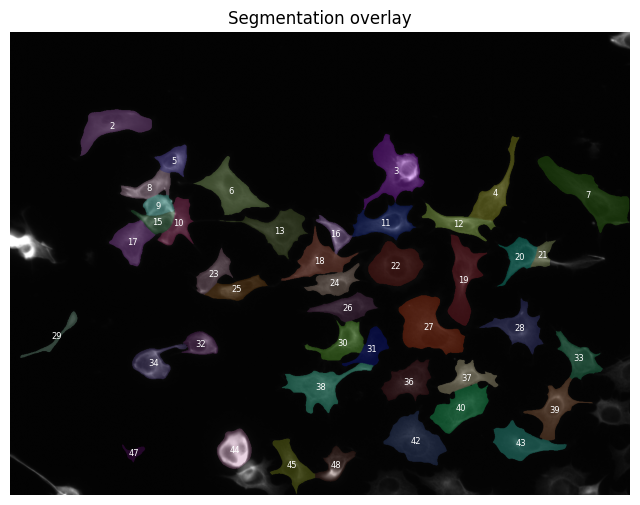

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [47]:
overlay_labels(image_2, labeled_mask_2)

Now it is absolutely necessary to add a column that identifies where the data came from. In this case we (like above) use the image name as identifier.

In [48]:
# First we add a new column that uniquely identifies each cell in the second dataframe.
df_2["cell_id"] = (
    df_2.index + 1
)  # we add 1 to the index to get the correct cell ID corresponding to the label IDs in the labeled mask, which start at 1

In [49]:
# add a column to each DataFrame that contains the image ID (e.g., F01_202w1 and F02_92w1)
df_2["image_id"] = image_path_2.stem
print("Second DataFrame with image_id column:")
print(df_2[["image_id"]].head())
print()
print("First DataFrame with image_id column:")
print(df[["image_id"]].head())

Second DataFrame with image_id column:
  image_id
0   F02_92
1   F02_92
2   F02_92
3   F02_92
4   F02_92

First DataFrame with image_id column:
  image_id
0  F01_202
1  F01_202
2  F01_202
3  F01_202
4  F01_202


Now we can use the `concat` function in pandas to create a merged dataframe from the first and second ones.

In [50]:
# We use pd.concat to concatenate the two DataFrames along the rows (axis=0), which combines all the measurements from both images into a single DataFrame.
# The ignore_index=True argument resets the index of the resulting DataFrame so that it runs from 0 to n-1, where n is the total number of rows in the concatenated DataFrame.
df_combined = pd.concat([df, df_2], ignore_index=True)
print(df_combined)

       area  intensity_mean  intensity_std  intensity_max  intensity_min  \
0    5634.0      422.204295     198.333981         1118.0          132.0   
1    4728.0      764.301607     523.274140         3509.0          138.0   
2    7677.0      279.368894     125.690020         1069.0          118.0   
3    6824.0      433.457210     254.054528         1445.0          120.0   
4    9638.0      492.971571     267.211757         1934.0          123.0   
..      ...             ...            ...            ...            ...   
114  7180.0      318.474234     145.186551         1381.0           91.0   
115  5311.0     2293.158727    1245.594333         4095.0          170.0   
116  4999.0      327.422284     168.351988         1366.0          100.0   
117   918.0      121.674292      27.344323          218.0           72.0   
118  3597.0      851.481790     780.147753         4095.0          126.0   

      perimeter  intensity_mean_bg_subtracted  intensity_range  cell_id  \
0    376.877

There are lot's of `NaN` values in the lower part of the dataframe. Those correspond to entries that we have computed in the first dataframe but not the second.
To avoid this, we can use the parameter `join` and set it to `inner`. This way only columns that exist in both dataframes will be kept. `outer` retains all columns from both dataframes as we have seen above.

In [51]:
df_combined = pd.concat([df, df_2], ignore_index=True, join="inner")
print(df_combined)

       area  intensity_mean  intensity_std  intensity_max  intensity_min  \
0    5634.0      422.204295     198.333981         1118.0          132.0   
1    4728.0      764.301607     523.274140         3509.0          138.0   
2    7677.0      279.368894     125.690020         1069.0          118.0   
3    6824.0      433.457210     254.054528         1445.0          120.0   
4    9638.0      492.971571     267.211757         1934.0          123.0   
..      ...             ...            ...            ...            ...   
114  7180.0      318.474234     145.186551         1381.0           91.0   
115  5311.0     2293.158727    1245.594333         4095.0          170.0   
116  4999.0      327.422284     168.351988         1366.0          100.0   
117   918.0      121.674292      27.344323          218.0           72.0   
118  3597.0      851.481790     780.147753         4095.0          126.0   

      perimeter  cell_id image_id  
0    376.877200        1  F01_202  
1    516.416306

Now we don't have any `NaN`s anymore. But we have also lost all the new columns we generated on the first dataframe. It is therefore generally advised to merge dataframes before doing calculations or classifications or to perform them in parallel on all dataframes using e.g. a for loop.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Handle strings in DataFrames</mark>
It is often very handy to manipulate strings in a dataframe column. Especially when files are consistently named, this can save a lot of effort when categorising data.

For example: our images are called `F01_202w1` and `F02_92w1`. Say, `F01` would be the well with the control and `F02` is the well with a drug. We can use the `image_id` column to create a new column with those labels.

For that we can use the `.str` method on the `image_id` column, which allows us to do string operations like `split` in bulk.

In [52]:
# Step 0: create a dictionary that maps the well id to the experimental condition
dict_condition = {"F01": "control", "F02": "drug"}

# Step 1: Turn the image_id column into a string-like object
print("1. String-like object\n", df_combined["image_id"].str)

# Step 2: use split on '_' to split each entry into a list of two strings
print("\n2. Split strings\n", df_combined["image_id"].str.split("_"))

# Step 3: Select only the first entry of each list
print("\n3. Select first entry\n", df_combined["image_id"].str.split("_").str[0])

# Step 4: Replace the well id with the experimental condition
print(
    "\n4. Replace:\n",
    df_combined["image_id"].str.split("_").str[0].replace(dict_condition),
)

df_combined["condition"] = (
    df_combined["image_id"].str.split("_").str[0].replace(dict_condition)
)

1. String-like object

2. Split strings
 0      [F01, 202]
1      [F01, 202]
2      [F01, 202]
3      [F01, 202]
4      [F01, 202]
          ...    
114     [F02, 92]
115     [F02, 92]
116     [F02, 92]
117     [F02, 92]
118     [F02, 92]
Name: image_id, Length: 119, dtype: object

3. Select first entry
 0      F01
1      F01
2      F01
3      F01
4      F01
      ... 
114    F02
115    F02
116    F02
117    F02
118    F02
Name: image_id, Length: 119, dtype: object

4. Replace:
 0      control
1      control
2      control
3      control
4      control
        ...   
114       drug
115       drug
116       drug
117       drug
118       drug
Name: image_id, Length: 119, dtype: object


### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Saving DataFrames as CSV</mark>
A key advantage of the DataFrame is that it can be stored as a CSV (comma separated values) file that can be opened in Excel, Prism, R or any other data analysis software.

For that we simply use the `.to_csv` method on a DataFrame.

In [ ]:
# index=False ensures that the index column of the dataframe is not saved with the rest of the data
df_combined.to_csv("combined_measurements.csv", index=False)

To load a CSV file into a Dataframe, we use the `read_csv` function.

In [ ]:
df_loaded = pd.read_csv("combined_measurements.csv")
print(df_loaded)

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Concluding remarks on `pandas`</mark>

This is only a brief overview of the capabilities of pandas. 

There are several great resources that go deeper. Check out the [pandas tutorials](https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html) or [community tutorials](https://pandas.pydata.org/docs/getting_started/tutorials.html).

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Success</mark>
Now we have a tidy table that contains all cells of the control and drug treated conditions and their corresponding properties, including `area` and `intensity_mean`. This will allow us to make a statement about the effect of the drug and maybe answer our question, which was: **Do drug treated cells exhibit changes in F-actin abundance or size?**

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Plotting results with `seaborn`</mark>
To plot results contained in a DataFrame, we can use the `seaborn` plotting library which is based on `matplotlib` and allows for straightforward usage of categorical and numerical data and gives access to standard plots like **bar graphs**, **violin plots**, **histograms**, **heatmaps**, **line plots**, **regression plots**, etc. See the [seaborn gallery](https://seaborn.pydata.org/examples/index.html) for inspiration.

In [53]:
import seaborn as sns

# Specifying some figure aesthetics
sns.set_context("poster")
sns.set_style("ticks")

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Histogram</mark>
A great tool for looking at distributions of values. Here we use the `histplot` function. Unlike in matplotlib we do not hand lists or arrays to the `x` (and `y`) parameters; instead we specify a DataFrame as `data` and assign columns as `x` (and later `y`).

<Axes: xlabel='area', ylabel='Count'>

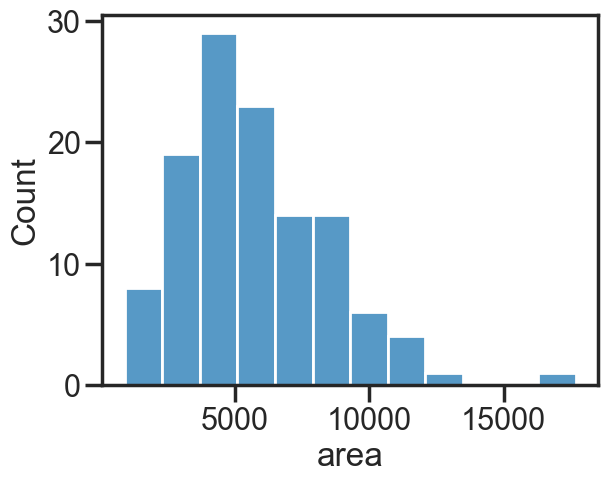

In [54]:
sns.histplot(data=df_combined, x="area")

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Box plot</mark>
One common way of displaying results is as a box plot. Here we use the `boxplot` function to create one. 

<Axes: xlabel='condition', ylabel='intensity_mean'>

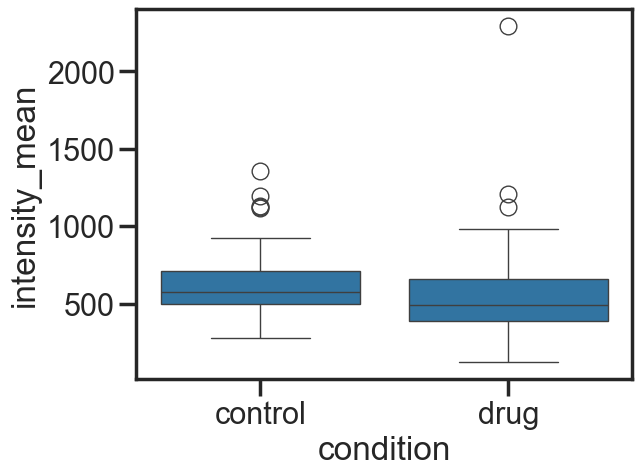

In [55]:
sns.boxplot(data=df_combined, x="condition", y="intensity_mean")

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Violin plot</mark>
To generate a violin plot we use the `violinplot` function. Note that the arguments of the plotting function are conserved between `violinplot` and `boxplot`. This is the case for most seaborn plotting functions. Moreover, since seaborn is using matplotlib, we can use matplotlib commands to adjust the figure. Here we add a grid and change the axis labels.

Text(0, 0.5, 'mean intensity (AU)')

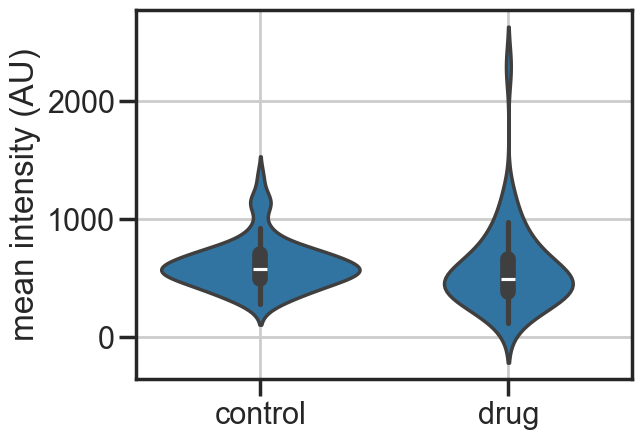

In [56]:
sns.violinplot(data=df_combined, x="condition", y="intensity_mean")
plt.grid()  # add grid
plt.xlabel("")  # remove x label
plt.ylabel("mean intensity (AU)")  # overwrite y label

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Bar graph</mark>
The seaborn function for that is `barplot` and it follows the same pattern as the two previous plots. Here we demonstrate another very useful function of seaborn plots which is splitting data by a second category. 

Say, we would like to explore the difference in expression between the control and drug is driven by higher expression only in small cells. After generating size categories based on their area, we can use the `hue` parameter to split each condition into several bars. This of course also works for the plots above.

In [57]:
# Create new column that categorises cells as 'small', 'medium' and 'large' as we did before
df_combined["size_category"] = pd.cut(
    df_combined["area"],
    bins=[0, 4000, 8000, np.inf],
    labels=["small", "medium", "large"],
)

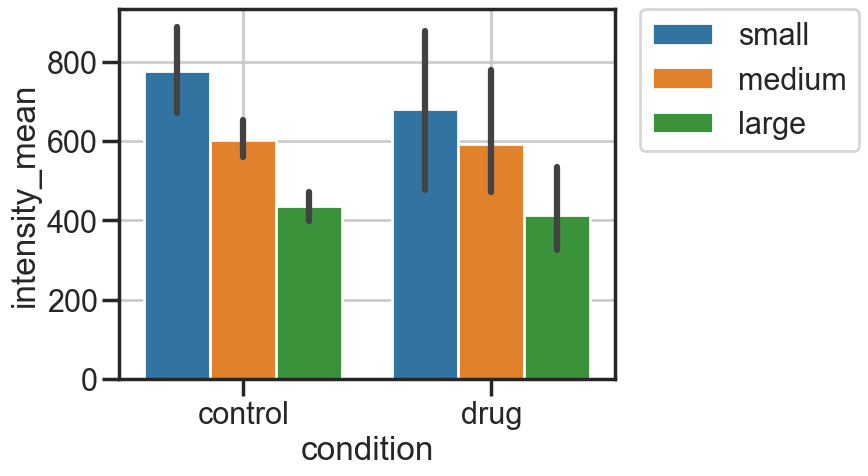

In [58]:
sns.barplot(
    data=df_combined,
    x="condition",
    y="intensity_mean",
    hue="size_category",
)
plt.grid()
# move legend outside of the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Scatter plot</mark>
To plot two continuous variables against each other we can use `scatterplot`.

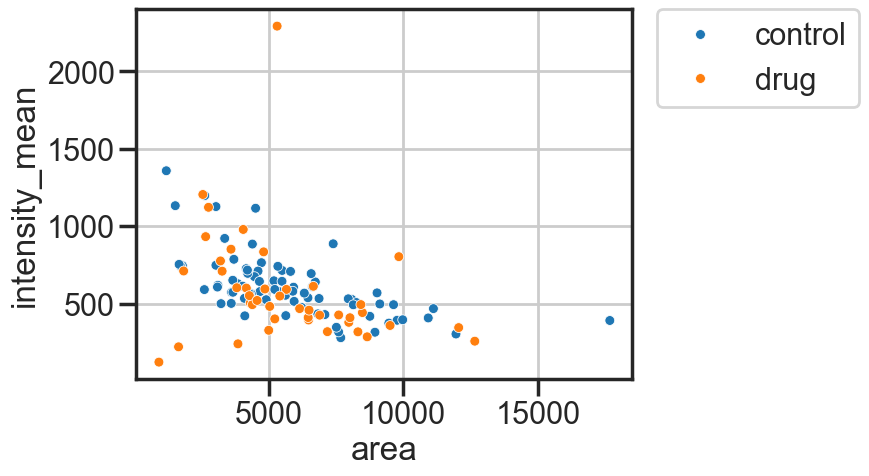

In [59]:
sns.scatterplot(
    data=df_combined,
    x="area",
    y="intensity_mean",
    hue="condition",
    s=50,  # controls the size of the dots
)
plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Plot the results for area changes</mark>
1. Create a violinplot that shows the differences in cell size between control and drug treatment.
2. Classify `intensity_mean` into `low` and `high` using the threshold `750` and plot `area` by `condition` split by this classification.
3. Create `swarmplot`s for `area` by `condition` and `intensity_mean` by `condition`. Look up `swarmplot` in the seaborn documentation.

Text(0, 0.5, 'mean intensity (AU)')

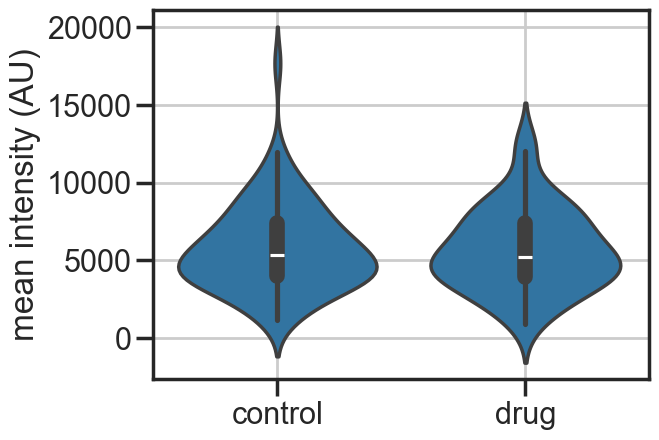

In [60]:
sns.violinplot(data=df_combined, x="condition", y="area")
plt.grid()  # add grid
plt.xlabel("")  # remove x label
plt.ylabel("mean intensity (AU)")  # overwrite y label

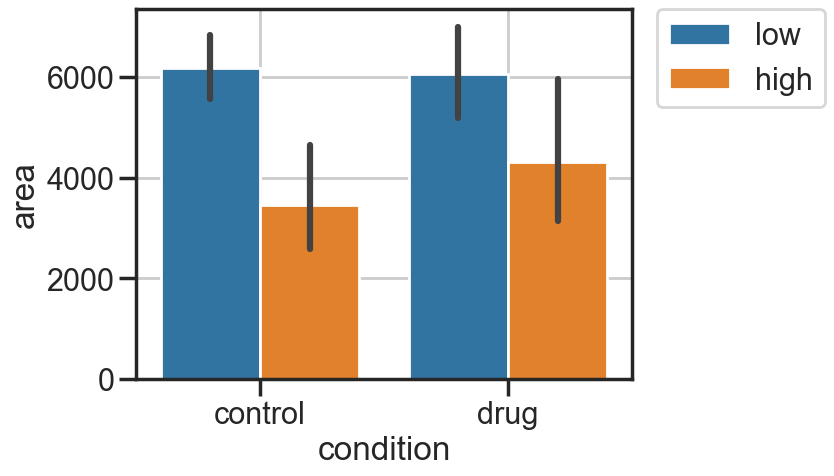

In [61]:
df_combined["expression"] = pd.cut(
    df_combined["intensity_mean"], bins=[0, 750, np.inf], labels=["low", "high"]
)
sns.barplot(
    data=df_combined,
    x="condition",
    y="area",
    hue="expression",
)
plt.grid()
# move legend outside of the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Bringing it all together - batch processing</mark>
To process more than a hand full of images, we can automate the measurement process. 

In [73]:
properties = [
    "area",
    "intensity_mean",
    "label",
]

image_folder = Path("/Users/max/Desktop/bobiac_data/04_05_06_07_seg_and_spot")
mask_folder = Path("/Users/max/Desktop/bobiac_data/04_05_06_07_seg_and_spot_labels_and_spots_coords/cells_labels")

images = sorted(image_folder.glob("*.tif"))
masks = sorted(mask_folder.glob("*tif"))

list_df = []

for i, image_path in enumerate(images):
    mask_path = masks[i]
    img_name = image_path.stem

    # load the image and label mask
    image = tifffile.imread(image_path)[1, :, :]
    mask = tifffile.imread(mask_path)
    mask = skimage.segmentation.clear_border(mask)  # remove boundary objects

    # compute region properties for the second image
    props = skimage.measure.regionprops_table(
        mask, intensity_image=image, properties=properties
    )
    sdf = pd.DataFrame(props)

    # create additional columns for book keeping
    sdf["image_id"] = img_name

    if img_name[:3] == "F01":
        condition = "control"
    elif img_name[:3] == "F02":
        condition = "drug"
    else:
        condition = "unknown"
    sdf["condition"] = condition

    # add dataframe to a list
    list_df.append(sdf)
# combine all dataframes into one
df_full = pd.concat(list_df)

In [75]:
df_plot = (
    df_full.groupby(["condition", "image_id"])[["area", "intensity_mean"]]
    .mean()
    .reset_index()
)

In [76]:
print(df_plot)

   condition image_id         area  intensity_mean
0    control  F01_202  5792.171053      613.218862
1    control  F01_204  5795.350000      650.675463
2    control  F01_291  6880.835821      442.783777
3    control  F01_366  7671.062500      559.852406
4    control  F01_508  5659.150943      838.700329
5    control  F01_589  3109.155039      569.854286
6       drug  F02_110  5249.031250      610.595584
7       drug  F02_321  4117.043478      584.439157
8       drug  F02_370  7186.200000      596.836724
9       drug  F02_696  6556.510204      579.760313
10      drug  F02_776  4259.308642      568.131303
11      drug   F02_92  5698.465116      576.990540


<Axes: xlabel='condition', ylabel='intensity_mean'>

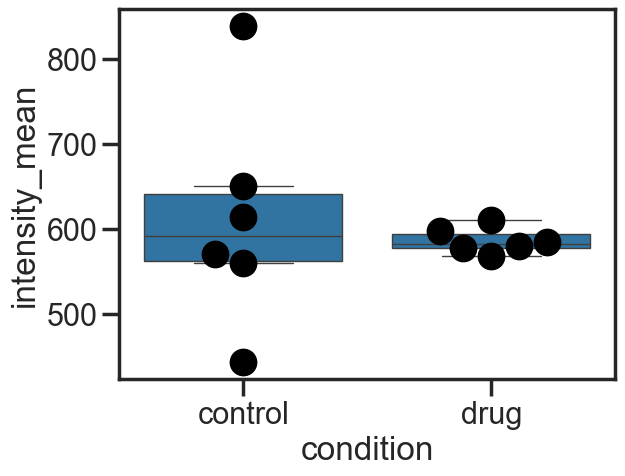

In [77]:
sns.boxplot(
    data=df_plot,
    x="condition",
    y="intensity_mean",
)

sns.swarmplot(data=df_plot, x="condition", y="intensity_mean", c="k", s=20)

<Axes: xlabel='condition', ylabel='area'>

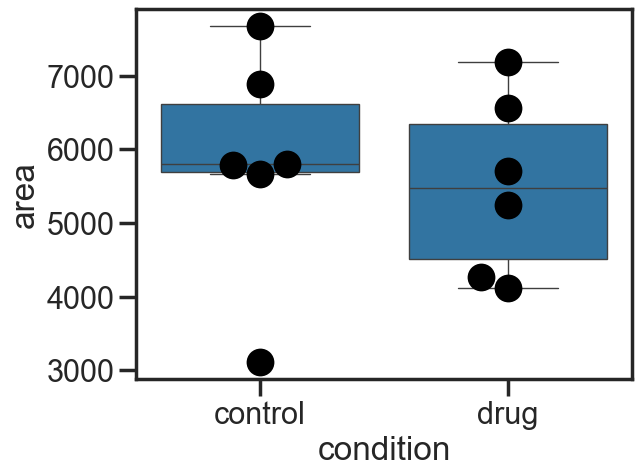

In [78]:
sns.boxplot(
    data=df_plot,
    x="condition",
    y="area",
)

sns.swarmplot(data=df_plot, x="condition", y="area", c="k", s=20)

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Conclusion</mark>
We successfully measured properties of cells and compared them with each other. In the following notebooks we will explore two common types of analysis: nested measurements and time series data. Now that we know `regionprops_table`, `pandas` and `seaborn` this will be relatively straightforward.